In [1]:
import yaml, torch, sys, json, random, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from types import SimpleNamespace
from PIL import Image, ImageFont, ImageDraw
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from datasets import load_dataset

from collections import defaultdict

import colorsys


sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device
# import random



In [2]:
def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_03_06.yaml') as f:
    config.update(yaml.safe_load(f))

config = to_namespace(config)
set_seed(config.seed)
device = get_device()
RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)
data_dir = Path('./EX_03_06/Raw/')

[device] using cuda


for the substrate model, make the input a color square. or give it the color somehow. 

In [3]:
def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

def bandwtn(image):
    # image shape: (B, C, H, W)
    if image.shape[1] == 3:
        gray = (
            0.299 * image[:, 0:1] +
            0.587 * image[:, 1:2] +
            0.114 * image[:, 2:3]
        )
        # repeat to 3 channels to match input
        return gray.repeat(1, 3, 1, 1)
    
    elif image.shape[1] == 1:
        # already grayscale, just return
        return image
    
    else:
        raise ValueError(f"Unsupported number of channels: {image.shape[1]}")

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)


def blur(x, blur_type, kernel_size=3, **kwargs):
    if blur_type == "box":
        return box_blur(x, kernel_size=kernel_size, **kwargs)
    elif blur_type == "gauss":
        return TF.gaussian_blur(x, kernel_size=[kernel_size, kernel_size], 
                                sigma=kwargs.get("sigma", 1.0))
    else:
        raise ValueError(f"unknown blur_type: {blur_type}")

In [4]:
DIGITS    = list("0123456789")                       # 10 — keep all
UPPERCASE = list("AEFHKLMNPRTVWXY")                   # 15 — dropped B(8) C(O) D(O) G(6) I(1) J(I) O(0) Q(O) S(5) U(V) Z(2)
LOWERCASE = list("adefhnrt")                          # 8  — EMNIST-distinct minus b(8) g(9) q(9)
FMNIST    = ["tshirt","trouser","pullover","dress","coat",
             "sandal","shirt","sneaker","bag","ankleboot"]  # 10
SYMBOLS   = list("★♥●▲■◆✚▼◀▶⬟⬢")                    # 12

CLASSES = (
    [("digit",  c) for c in DIGITS]    +
    [("upper",  c) for c in UPPERCASE] +
    [("lower",  c) for c in LOWERCASE] +
    [("fmnist", i) for i in range(len(FMNIST))] +
    [("symbol", c) for c in SYMBOLS]
)
NUM_CLASSES = len(CLASSES)  # 55
SOURCES_FOR_KIND = {
    "digit":  ["mnist", "font_inter", "font_serif"],
    "upper":  ["emnist", "font_inter", "font_serif"],
    "lower":  ["emnist"],
    "fmnist": ["fmnist"],
    "symbol": ["font_symbols"],
}

# EMNIST balanced label → char mapping (47 classes)
EMNIST_BALANCED_CHARS = (
    list("0123456789") +
    list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") +
    list("abdefghnqrt")
)

FONT_PATHS = {
    "inter":   "../../shared_models/assets/Helvetica-Bold.ttf",
    "serif":   "../../shared_models/assets/AppleGaramond-Bold.ttf",
    "symbols": "../../shared_models/assets/NotoSansSymbols2-Regular.ttf",
}

PALETTE = torch.tensor([
    [0.10, 0.10, 0.10],   # near-black
    [0.55, 0.10, 0.10],   # dark red
    [0.10, 0.40, 0.15],   # dark green
    [0.10, 0.20, 0.55],   # dark blue
    [0.55, 0.45, 0.10],   # dark yellow / olive
    [0.50, 0.15, 0.50],   # dark magenta
    [0.10, 0.45, 0.50],   # dark teal
    [0.45, 0.30, 0.15],   # dark brown / sienna
])
NUM_COLORS = len(PALETTE)

def _idx_by_label(targets, label_to_key):
    idx = {k: [] for k in label_to_key.values()}
    arr = targets.numpy() if torch.is_tensor(targets) else targets
    for i, lbl in enumerate(arr):
        key = label_to_key.get(int(lbl))
        if key is not None:
            idx[key].append(i)
    return idx

def _render_font_glyph(char, font, size):
    img  = Image.new("L", (size, size), 0)
    draw = ImageDraw.Draw(img)
    bbox = draw.textbbox((0, 0), char, font=font)
    x = (size - (bbox[2] - bbox[0])) // 2 - bbox[0]
    y = (size - (bbox[3] - bbox[1])) // 2 - bbox[1]
    draw.text((x, y), char, fill=255, font=font)
    return TF.to_tensor(img)  # (1, size, size)

def _emnist_fix(pil_img):
    # EMNIST is stored transposed; this is the canonical un-transpose.
    return pil_img.transpose(Image.TRANSPOSE)

def glyph_bgrnd(size, bg_type):
    if bg_type == "blank":
        return torch.zeros(3, size, size)
    raise ValueError(f"unknown bg_type: {bg_type}")

class UnifiedGlyphDataset(Dataset):
    def __init__(self, num_samples=60000, size=28, bg_type="blank"):
        self.num_samples = num_samples
        self.size = size
        self.bg_type = bg_type

        # Raw datasets (no transform — we handle PIL → tensor by hand)
        self.mnist  = datasets.MNIST(root="../../data/", train=True, download=True)
        self.emnist = datasets.EMNIST(root="../../data/", split="balanced",
                                       train=True, download=True)
        self.fmnist = datasets.FashionMNIST(root="../../data/", train=True, download=True)

        # Per-class index lookups (built once via .targets, fast)
        self.mnist_idx  = _idx_by_label(
            self.mnist.targets,
            {i: str(i) for i in range(10)},
        )
        emnist_label_to_char = {
            i: c for i, c in enumerate(EMNIST_BALANCED_CHARS)
            if c in set(UPPERCASE + LOWERCASE)
        }
        self.emnist_idx = _idx_by_label(self.emnist.targets, emnist_label_to_char)
        self.fmnist_idx = _idx_by_label(
            self.fmnist.targets,
            {i: i for i in range(10)},
        )

        # Fonts — sized per source so glyphs fit the 28px box even when bold
        self.fonts = {
            "inter":   ImageFont.truetype(FONT_PATHS["inter"],   size=int(size * 0.95)),
            "serif":   ImageFont.truetype(FONT_PATHS["serif"],   size=int(size * 0.95)),
            "symbols": ImageFont.truetype(FONT_PATHS["symbols"], size=int(size * 0.80)),
        }

    def __len__(self):
        return self.num_samples

    def _get_glyph(self, kind, key):
        source = random.choice(SOURCES_FOR_KIND[kind])

        if source == "mnist":
            i = random.choice(self.mnist_idx[key])
            pil, _ = self.mnist[i]
            return TF.to_tensor(pil)
        if source == "emnist":
            i = random.choice(self.emnist_idx[key])
            pil, _ = self.emnist[i]
            return TF.to_tensor(_emnist_fix(pil))
        if source == "fmnist":
            i = random.choice(self.fmnist_idx[key])
            pil, _ = self.fmnist[i]
            return TF.to_tensor(pil)
        if source == "font_inter":
            return _render_font_glyph(key, self.fonts["inter"], self.size)
        if source == "font_serif":
            return _render_font_glyph(key, self.fonts["serif"], self.size)
        if source == "font_symbols":
            return _render_font_glyph(key, self.fonts["symbols"], self.size)
        raise ValueError(f"unknown source: {source}")

    def __getitem__(self, idx):
        label = random.randrange(NUM_CLASSES)
        kind, key = CLASSES[label]
        glyph = self._get_glyph(kind, key)

        background   = glyph_bgrnd(self.size, self.bg_type)
        comp         = torch.cat([background, glyph], dim=0)
        color_idx = random.randrange(NUM_COLORS)   # 0..7
        target_color = PALETTE[color_idx]
        return comp, label, target_color



# ============================================================
# n = 100
n = 60000
ex03_06_trainset = UnifiedGlyphDataset(num_samples=n)
train_size = int(0.9 * n)
val_size   = n - train_size
train_set, val_set = random_split(
    ex03_06_trainset, [train_size, val_size],
    generator=torch.Generator().manual_seed(config.seed)
)

ex03_06_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex03_06_valloader   = DataLoader(val_set,   batch_size=config.batch_size)

In [71]:
len(ex03_06_trainset)

60000

# Better Painter Model

In [5]:
from datasets import load_dataset
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt

class GalaxyStyleDataset(Dataset):
    def __init__(self, size=28, split="train", n_samples=500):
        ds = load_dataset("Smith42/galaxies", split=split, streaming=True)
        
        transform = T.Compose([
            T.Resize((size, size), interpolation=T.InterpolationMode.BILINEAR),
            T.ToTensor(),
        ])
        
        self.imgs = []
        for i, sample in enumerate(ds):
            if i >= n_samples:
                break
            img = sample["image_crop"].convert("RGB")
            self.imgs.append(transform(img))
        
        self.imgs = torch.stack(self.imgs)
        print(f"Loaded {len(self.imgs)} galaxy images at {size}x{size}")
    
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        return self.imgs[idx]


# class GalaxyWrapper(Dataset):
#     def __init__(self, base_dataset, galaxy_imgs):
#         self.base = base_dataset
#         self.galaxies = galaxy_imgs
    
#     def __len__(self):
#         return len(self.base)
    
#     def __getitem__(self, idx):
#         comp, label, target_color = self.base[idx]
#         gal_idx = torch.randint(0, len(self.galaxies), (1,)).item()
#         galaxy = self.galaxies[gal_idx]
#         return comp, label, target_color, galaxy

class GalaxyWrapper(Dataset):
    def __init__(self, base_dataset, galaxy_imgs):
        self.base = base_dataset
        self.galaxies = galaxy_imgs[:NUM_COLORS]
    
    def __len__(self):
        return len(self.base)
    
    def __getitem__(self, idx):
        comp, label, target_color = self.base[idx]
        color_idx = (PALETTE == target_color).all(dim=1).nonzero()[0].item()
        galaxy = self.galaxies[color_idx]
        return comp, label, target_color, galaxy


# Build once, save to disk for fast reload later
# galaxy_dataset = GalaxyStyleDataset(size=28, n_samples=500)
# torch.save(galaxy_dataset.imgs, "./data/galaxy_28x28_500.pt")



# # Verify
# fig, axes = plt.subplots(1, 5, figsize=(15, 3))
# for i, ax in enumerate(axes):
#     idx = torch.randint(0, len(galaxy_dataset), (1,)).item()
#     img = galaxy_dataset[idx].permute(1, 2, 0)
#     ax.imshow(img)
#     ax.axis("off")
# plt.tight_layout()
# plt.show()

In [6]:
galaxy_imgs = torch.load("data/galaxy_28x28_500.pt", weights_only=True)
ex03_06a_dataset = GalaxyWrapper(ex03_06_trainset, galaxy_imgs)
train_size = int(0.9 * n)
val_size   = n - train_size
train_set_a, val_set_a = random_split(
    ex03_06a_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(config.seed)
)
ex03_06a_trainloader = DataLoader(train_set_a, batch_size=config.batch_size, shuffle=True)
ex03_06a_valloader   = DataLoader(val_set_a,   batch_size=config.batch_size)

In [7]:
from torchvision.models import vgg19, VGG19_Weights

class VGGStyleExtractor(nn.Module):
    """Extract activations at conv1_1, conv2_1, conv3_1, conv4_1 from VGG19."""
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features
        for p in vgg.parameters():
            p.requires_grad = False
        # conv1_1 = layer 1, conv2_1 = layer 6, conv3_1 = layer 11, conv4_1 = layer 20
        # Skipping conv5_1 to save compute — early layers carry texture info
        self.style_layers = [1, 6, 11, 20]
        self.vgg = vgg.eval()
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    
    def forward(self, x):
        # x: (B, 3, 28, 28) in [0, 1]
        # Upsample to 112x112 (smaller than 224 to save compute, still gets meaningful features)
        x = F.interpolate(x, size=(112, 112), mode="bilinear", align_corners=False)
        x = (x - self.mean) / self.std
        feats = []
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            if i in self.style_layers:
                feats.append(x)
            if i >= max(self.style_layers):
                break
        return feats


def gram_matrix(feat):
    """feat: (B, C, H, W) → (B, C, C) normalized gram matrix."""
    B, C, H, W = feat.shape
    f = feat.view(B, C, H * W)
    G = torch.bmm(f, f.transpose(1, 2)) / (C * H * W)
    return G


def gram_style_loss(generated, style_target, vgg_extractor):
    gen_feats   = vgg_extractor(generated)
    style_feats = vgg_extractor(style_target)
    loss = 0
    for gf, sf in zip(gen_feats, style_feats):
        loss = loss + F.mse_loss(gram_matrix(gf), gram_matrix(sf))
    return loss / len(gen_feats)


# Initialize once
vgg_extractor = VGGStyleExtractor().to(device)

In [8]:
class PainterNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        in_dim = NUM_CLASSES + 2 + 3   # 55 + 2 + 3 = 60
        
        self.fc = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 7 * 7 * 32),
            nn.ReLU(),
        )
        
        
        self.deconv = nn.Sequential(
            nn.Unflatten(1, (32, 7, 7)),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        return self.deconv(self.fc(x))
        
def ex_03_06a_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):

    _, label, target_color, galaxy_bgrnd = batch  # we don't need the glyph for the painter alone
    target_color = target_color.to(device)
    B = target_color.shape[0]
    
    noise = torch.randn(B, 2, device=device)
    # noise = torch.zeros(B, 2, device=device)
    fake_label = F.one_hot(label, num_classes=NUM_CLASSES).float()
    x = torch.cat([fake_label, noise, target_color], dim=1)
    generated = model(x)
    
    # === 1. Color match on blur===
    blur_type = config.variants.a.blur_fn
    blurred = blur(generated,blur_type)
    target_map = target_color.view(B, 3, 1, 1).expand_as(blurred)
    color_loss = F.mse_loss(blurred, target_map)
    
    # === 2. galaxy ===
    style_loss = F.mse_loss(generated, galaxy_bgrnd)
    # style_loss = gram_style_loss(generated, galaxy_bgrnd, vgg_extractor)
    # gen_centered = generated - generated.mean(dim=[2,3], keepdim=True)
    # gal_centered = galaxy_bgrnd - galaxy_bgrnd.mean(dim=[2,3], keepdim=True)
    # style_loss = F.mse_loss(gen_centered, gal_centered)

    
    # # === 4. Total variation, capped ===
    # # Penalize TV that exceeds a target. Uncapped TV would push to solid color.
    # dh = (generated[:, :, 1:, :] - generated[:, :, :-1, :]).abs().mean()
    # dw = (generated[:, :, :, 1:] - generated[:, :, :, :-1]).abs().mean()
    # tv = dh + dw
    # tv_target = 0.15
    # tv_loss = (tv - tv_target).abs()
    
    # === 5. Diversity: split batch in half, penalize mean-similarity ===
    # half = B // 2
    # if half > 0:
    #     a = generated[:half]
    #     b = generated[half:half * 2]
    #     # Mean L2 distance between paired samples — want this LARGE
    #     pairwise = ((a - b) ** 2).mean(dim=[1, 2, 3])
    #     div_loss = -pairwise.mean()  # negative because we want large distances
    # else:
    #     div_loss = torch.tensor(0.0, device=device)
    
    loss = (
        config.variants.a.color_loss_w * color_loss +
        config.variants.a.style_loss_w * style_loss 
        # config.variants.a.tv_loss_w * tv_loss +
        # config.variants.a.div_loss_w * div_loss
    )
    # loss = style_loss
    
    if mode == "val":
        return {
            "val_loss":    loss.item(),
            "color_loss":  color_loss.item(),
            "style_loss":   style_loss.item(),
            # "spatial_std": spatial_std.item(),
            # "tv":          tv.item(),
            # "div_dist":    -div_loss.item(),
        }
    return loss



EX_03_06a_info = {
    "exp_id":      "EX_03_06a",
    "epochs":      10,
    "log_to":      "file", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

In [9]:
# ex_03_06a_model = PainterNetwork()
# optimizer = torch.optim.Adam(ex_03_06a_model.parameters(), lr=0.0005)
# run_experiment(
#     model=ex_03_06a_model,
#     optimizer=optimizer,
#     loss_fn=ex_03_06a_loss_fn,
#     train_loader=ex03_06a_trainloader,
#     val_loader=ex03_06a_valloader,
#     config=EX_03_06a_info,
#     log_to=EX_03_06a_info["log_to"],
# )

ex_03_06a_model = PainterNetwork().to(device)
ex_03_06a_model.load_state_dict(torch.load('Model/A/EX_03_06a_final.pt', map_location=device, weights_only=True))
ex_03_06a_model.eval()

PainterNetwork(
  (fc): Sequential(
    (0): Linear(in_features=60, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
  )
  (deconv): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (1): Upsample(scale_factor=2.0, mode='bilinear')
    (2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Upsample(scale_factor=2.0, mode='bilinear')
    (5): Conv2d(16, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Sigmoid()
  )
)

max diff: 0.021079301834106445


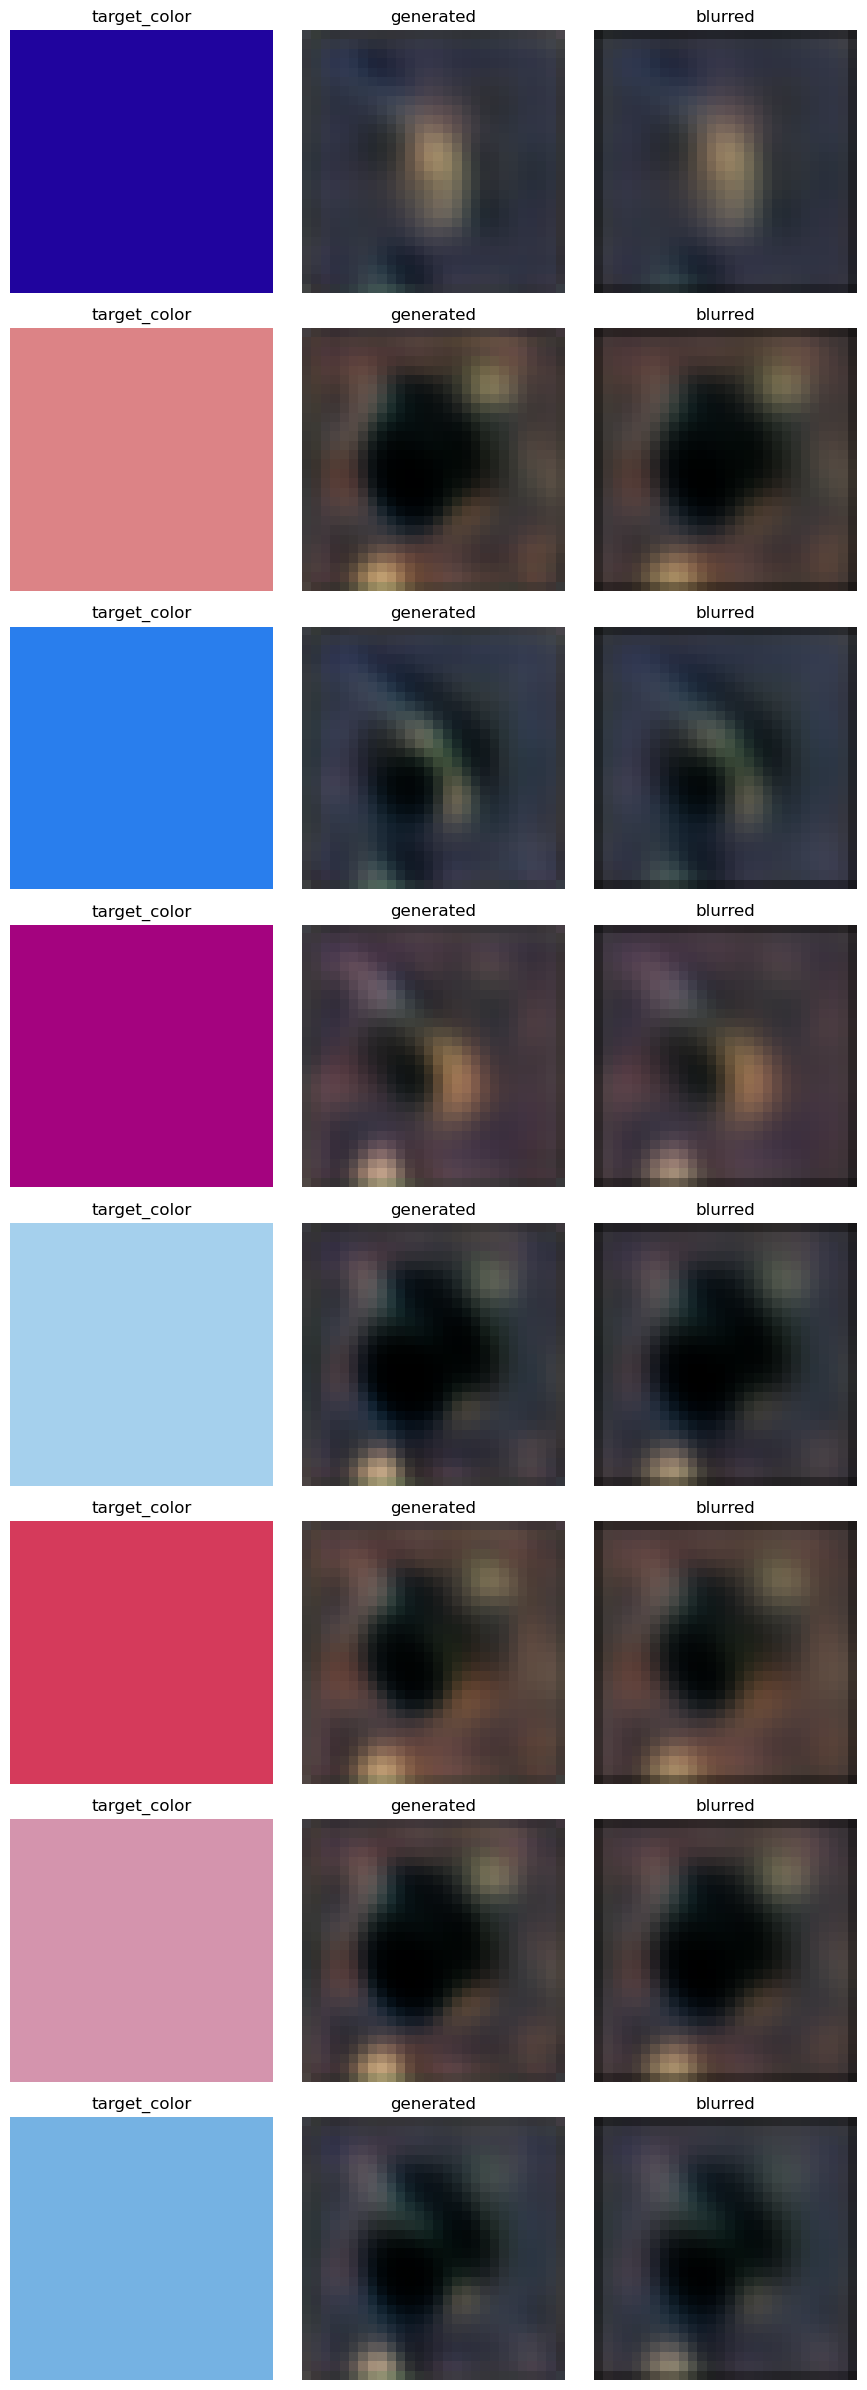

In [154]:
@torch.no_grad()
def show_painter_06(model, n=8, device="cuda"):
    model.eval().to(device)
    
    def make_input(target_color, noise=None):
        B = target_color.shape[0]
        if noise is None:
            noise = torch.randn(B, 2, device=device)
        # Painter ignores label, but interface requires it — use zeros
        fake_label = torch.zeros(B, NUM_CLASSES, device=device)
        return torch.cat([fake_label, noise, target_color], dim=1)
    
    # Sanity: same color, different noise → different output?
    target_color = torch.tensor([[0.5, 0.3, 0.7]], device=device)
    out1 = model(make_input(target_color))
    out2 = model(make_input(target_color))
    print("max diff:", (out1 - out2).abs().max().item())
    
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    for row in range(n):
        target_color = torch.rand(1, 3, device=device)
        gen = model(make_input(target_color))
        blurred = blur(gen, "box")
        
        axes[row, 0].imshow(target_color.view(3,1,1).expand(3,28,28).permute(1,2,0).cpu())
        axes[row, 0].set_title("target_color")
        axes[row, 1].imshow(gen.squeeze(0).permute(1,2,0).cpu().clamp(0,1))
        axes[row, 1].set_title("generated")
        axes[row, 2].imshow(blurred.squeeze(0).permute(1,2,0).cpu().clamp(0,1))
        axes[row, 2].set_title("blurred")
        for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.show()

show_painter_06(ex_03_06a_model)

# Full Model, Part 2

In [10]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel_allGlyphs(nn.Module):
    def __init__(self, num_classes=55):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 5, padding=2)   
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.fc1   = nn.Linear(32*5*5, 240)
        self.fc2   = nn.Linear(240, 168)
        self.fc3   = nn.Linear(168, num_classes)
        self.dropout = nn.Dropout(0.2)
    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return self.fc3(x)

ex_03_04a_model = LeNet3channel_allGlyphs().to(device)
ex_03_04a_model.load_state_dict(torch.load('../../Epic_3/EX_03_04/Model/A/EX_03_04a_final.pt', map_location=device, weights_only=True))
ex_03_04a_model.eval()


LeNet3channel_allGlyphs(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=240, bias=True)
  (fc2): Linear(in_features=240, out_features=168, bias=True)
  (fc3): Linear(in_features=168, out_features=55, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [11]:

class HideNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 3 (substrate) + NUM_CLASSES (label map) channels
        #this feels weird but idk sorta makes sense. one hot would work too but then gotta deal with weird sizes. 
        # j makes the math clean. 
        in_channels = 3 + NUM_CLASSES
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),  # 28x28
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

# class HideNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         in_channels = 3 + NUM_CLASSES
#         self.net = nn.Sequential(
#             nn.Conv2d(in_channels, 32, 3, padding=1),
#             nn.ReLU(),
#             nn.Conv2d(32, 3, 3, padding=1),
#             nn.Sigmoid()
#         )
    
#     def forward(self, x):
#         return self.net(x)

class FullSystem(nn.Module):
    def __init__(self, painter, hider):
        super().__init__()
        self.painter = painter
        self.hider = hider
    
    # def forward(self, label_onehot, noise):
    #     substrate = self.painter(torch.cat([label_onehot, noise], dim=1))
    #     # broadcast label for hider
    #     B = label_onehot.shape[0]
    #     label_map = label_onehot.view(B, -1, 1, 1).expand(B, -1, 28, 28)
    #     hider_input = torch.cat([substrate, label_map], dim=1)
    #     public = self.hider(hider_input)
    #     return public, substrate  # return both for diagnostics
    def forward(self, label_onehot, noise, target_color):
        substrate = self.painter(torch.cat([label_onehot, noise, target_color], dim=1))
        B = label_onehot.shape[0]
        label_map = label_onehot.view(B, -1, 1, 1).expand(B, -1, 28, 28)
        hider_input = torch.cat([substrate, label_map], dim=1)
        public = self.hider(hider_input)
        return public, substrate

def ex_03_06b_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    comp, label, target_color = batch
    real_glyph = comp[:, 3:].to(device)
    
    # === Forward ===
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=NUM_CLASSES).float()

    public, substrate = model(onehot, noise, target_color)

    # === Blur for receiver-side decoding ===
    blur_type = config.variants.b.blur_fn  # parameterized blur
    # blurred_public = blur(public, blur_type, kernel_size=3)

    
    # pre-blur
    # public_1d = public.mean(dim=1, keepdim=True)
    # logits = ex_03_04a_model(public_1d)  # frozen pre-blur classifier
    # probs  = F.softmax(logits, dim=1)
    # conf_pre = probs[torch.arange(probs.shape[0]), label]  # (B,) confidence on correct class
    
    # post blur mse
    # Mask: only penalize within glyph region
    # blurred_public_1d = blurred_public.mean(dim=1, keepdim=True)
    # glyph_mask = (real_glyph > 0.5).float()
    # diff_sq = (blurred_public_1d - real_glyph) ** 2
    # post_loss = (diff_sq * glyph_mask).sum() / (glyph_mask.sum() + 1e-8)


    # glyph_mask = (real_glyph > 0.5).float()
    # diff_sq = (blurred_public_1d - real_glyph) ** 2
    # masked_post_loss = (diff_sq * glyph_mask).sum() / (glyph_mask.sum() + 1e-8)

    #similarity to substrate. 
    conf_pre    = F.mse_loss(public, substrate)

    
    
    bandwtn_public = bandwtn(public) 
    bandwtn_real = bandwtn(real_glyph)

    public_1d = bandwtn_public.mean(dim=1, keepdim=True)
    real_1d = bandwtn_real.mean(dim=1, keepdim=True)
    
    blurred_public = blur(public_1d, blur_type, kernel_size=9)
    blurred_real = blur(real_1d, blur_type, kernel_size=1)
    
 
    #bandwtn bc mnist is bandw, easier than trying to retrain and all we care about.
    post_loss    = F.mse_loss(blurred_public, blurred_real)
    
    # # Weak preservation: blurred public should resemble blurred substrate
    # # (where there's no glyph, just keep the substrate's structure)
    # blurred_substrate = blur(substrate, blur_type, kernel_size=3)
    # preservation_mask = 1.0 - glyph_mask
    # preservation_loss = (((blurred_public - blurred_substrate) ** 2) * preservation_mask.unsqueeze(1)).mean()
    
    # post_loss = masked_post_loss + 0.3 * preservation_loss
    
    # no curriculum for now
    alpha = 0.01 #config.variants.b.alpha
    beta  = 0.99 #config.variants.b.beta
    loss = alpha * conf_pre.mean() + beta * post_loss
    
    if mode == "val":
        return {
            "val_loss":   loss.item(),
            "pre_loss":   conf_pre.mean().item(),
            "post_loss":  post_loss.item(),
        }
    return loss

# ── RUN ───────────────────────────────────────────────────────────────────────
EX_03_06b_info = {
    "exp_id":      "EX_03_06b",
    "epochs":      10,# config.variants.b.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": config.variants.b.description
}



In [12]:

# ex_03_06b_hider = HideNetwork()
# ex_03_06b_model = FullSystem(painter=ex_03_06a_model, hider=ex_03_06b_hider)
# optimizer = torch.optim.Adam(ex_03_06b_model.hider.parameters(), lr=config.variants.b.lr)


# run_experiment(
#     model=ex_03_06b_model,
#     optimizer=optimizer,
#     loss_fn=ex_03_06b_loss_fn,
#     train_loader=ex03_06_trainloader,   # use the original loader, not the bootstrap wrapper
#     val_loader=ex03_06_valloader,
#     config=EX_03_06b_info,
#     log_to=EX_03_06b_info["log_to"],
# )

ex_03_06b_hider = HideNetwork()
ex_03_06b_model = FullSystem(painter=ex_03_06a_model, hider=ex_03_06b_hider).to(device)
ex_03_06b_model.load_state_dict(torch.load('../../Epic_3/EX_03_06/Model/B/EX_03_06b_final.pt', map_location=device, weights_only=True))
ex_03_06b_model.eval()

FullSystem(
  (painter): PainterNetwork(
    (fc): Sequential(
      (0): Linear(in_features=60, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1568, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): Unflatten(dim=1, unflattened_size=(32, 7, 7))
      (1): Upsample(scale_factor=2.0, mode='bilinear')
      (2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Upsample(scale_factor=2.0, mode='bilinear')
      (5): Conv2d(16, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): Sigmoid()
    )
  )
  (hider): HideNetwork(
    (net): Sequential(
      (0): Conv2d(58, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(16, 3, kernel_size=(3,

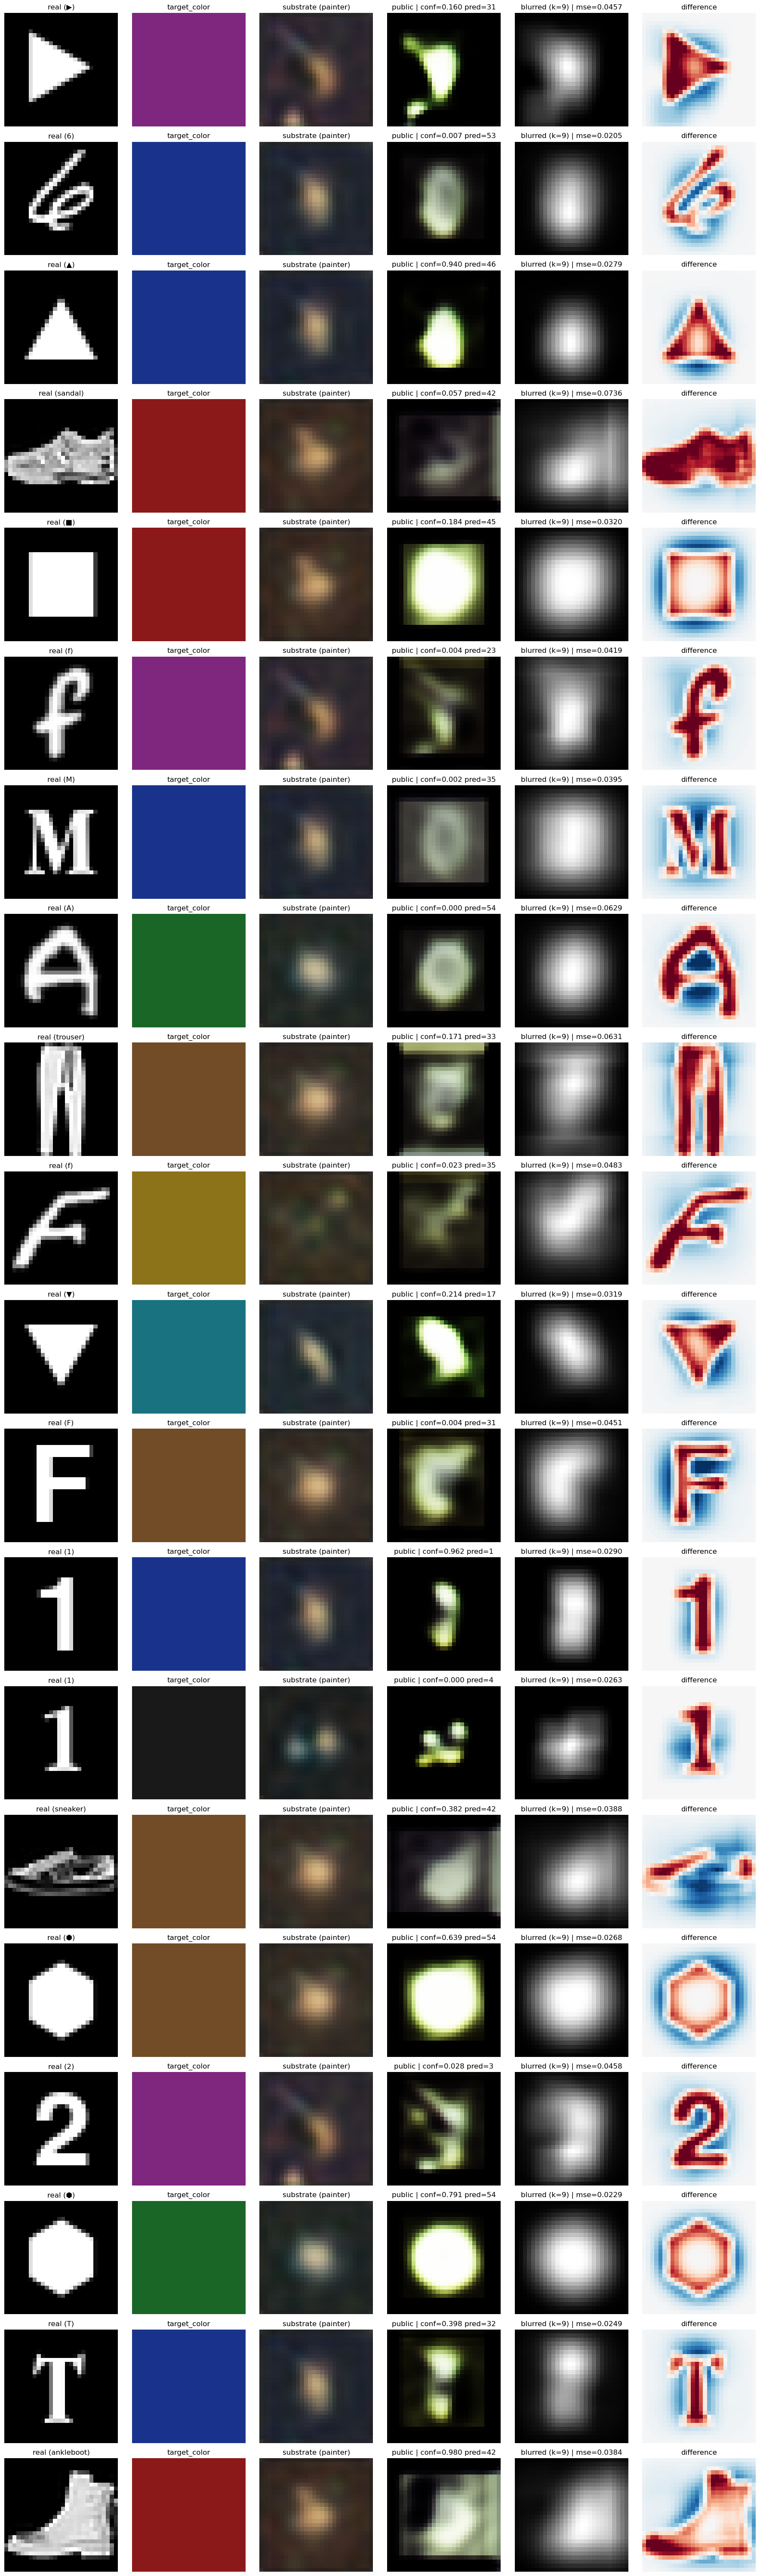

In [85]:
def label_to_str(label):
    kind, key = CLASSES[label]
    if kind == "fmnist":
        return FMNIST[key]
    return key
    
@torch.no_grad()
def show_full_system(model, dataset, n=5, device="cuda"):
    """
    Visualize the full painter -> hider pipeline.
    Matches loss-function blur setup: kernel=9 on public, kernel=2 on real_glyph.
    Columns: real glyph | target_color | substrate (painter) | public (hider) | blurred public | difference
    """
    model.eval().to(device)
    fig, axes = plt.subplots(n, 6, figsize=(18, 3 * n))
    if n == 1:
        axes = axes[None, :]
    
    blur_type = config.variants.b.blur_fn
    
    for row in range(n):
        idx = random.randint(0, len(dataset) - 1)
        comp, label, target_color = dataset[idx]
        target_color = target_color.to(device).float().unsqueeze(0)
        label_int = int(label)
        real_glyph = comp[3]  # (28, 28), single-channel glyph
        
        # Forward through full system
        label_t = torch.tensor([label_int], device=device)
        noise   = torch.randn(1, 2, device=device)
        onehot  = F.one_hot(label_t, num_classes=NUM_CLASSES).float()
        public, substrate = model(onehot, noise, target_color)
        
        # Match loss-function blurring: BW collapse, then kernel=9 on public, kernel=2 on real
        bandwtn_public = bandwtn(public)
        public_1d = bandwtn_public.mean(dim=1, keepdim=True)
        blurred_public_1d = blur(public_1d, blur_type, kernel_size=9)
        
        real_glyph_dev = real_glyph.unsqueeze(0).unsqueeze(0).to(device).float()
        bandwtn_real = bandwtn(real_glyph_dev)
        real_1d = bandwtn_real.mean(dim=1, keepdim=True)
        blurred_real_1d = blur(real_1d, blur_type, kernel_size=3)
        
        # Pre-blur classifier check
        public_for_clf = public.mean(dim=1, keepdim=True)
        logits = ex_03_04a_model(public_for_clf)
        probs  = F.softmax(logits, dim=1)
        conf_pre = probs[0, label_int].item()
        pred_pre = logits.argmax(dim=1).item()
        
        # Post-blur MSE — same as loss function (no mask, both blurred)
        post_loss = F.mse_loss(blurred_public_1d, blurred_real_1d).item()
        
        # Plot
        axes[row, 0].imshow(real_glyph, cmap="gray")
        axes[row, 0].set_title(f"real ({label_to_str(label_int)})")
        
        tc_img = target_color.squeeze(0).view(3, 1, 1).expand(3, 28, 28).permute(1, 2, 0).cpu()
        axes[row, 1].imshow(tc_img)
        axes[row, 1].set_title("target_color")
        
        axes[row, 2].imshow(substrate.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 2].set_title("substrate (painter)")
        
        axes[row, 3].imshow(public.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1))
        axes[row, 3].set_title(f"public | conf={conf_pre:.3f} pred={pred_pre}")
        
        # Show the actual blurred image (bw + heavy blur, what gets compared in loss)
        axes[row, 4].imshow(blurred_public_1d.squeeze().cpu(), cmap="gray")
        axes[row, 4].set_title(f"blurred (k=9) | mse={post_loss:.4f}")
        
        # Difference: blurred public vs blurred real, both at the same scale
        diff_vis = (blurred_public_1d.squeeze().cpu() - blurred_real_1d.squeeze().cpu())
        axes[row, 5].imshow(diff_vis, cmap="RdBu", vmin=-0.5, vmax=0.5)
        axes[row, 5].set_title("difference")
        
        for ax in axes[row]:
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()


show_full_system(ex_03_06b_model, ex03_06_trainset, n=20)

# GAUSSIAN

In [14]:
EX_03_06c_info = {
    "exp_id":      "EX_03_06c",
    "epochs":      config.variants.c.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/C",
    "log_dir":     "logs/C",
    "seed":        42,
    "notes": config.variants.c.description
}


ex_03_06c_hider = HideNetwork()
ex_03_06c_model = FullSystem(painter=ex_03_06a_model, hider=ex_03_06c_hider)
optimizer = torch.optim.Adam(ex_03_06c_model.hider.parameters(), lr=config.variants.b.lr)



run_experiment(
    model=ex_03_06c_model,
    optimizer=optimizer,
    loss_fn=ex_03_06b_loss_fn,
    train_loader=ex03_06_trainloader,   # use the original loader, not the bootstrap wrapper
    val_loader=ex03_06_valloader,
    config=EX_03_06c_info,
    log_to=EX_03_06c_info["log_to"],
)


# ex_03_06c_model.load_state_dict(torch.load('../../Epic_3/EX_03_06/Model/C/EX_03_06c_final.pt', map_location=device, weights_only=True))
# ex_03_06c_model.eval()

[device] using cuda


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /ihome/xli/sek188/.netrc.
wandb: Currently logged in as: sek188 (teamMaverick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
post_loss,█▅▄▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
pre_loss,▁▄▅▅▆▆▆▇▆▇▇▇▇▇▇▇▇██▇██▇██
train_loss,█▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▄▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
epoch,25
post_loss,0.06818
pre_loss,0.06684
train_loss,0.06858
val_loss,0.06817


FullSystem(
  (painter): PainterNetwork(
    (fc): Sequential(
      (0): Linear(in_features=60, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=1568, bias=True)
      (3): ReLU()
    )
    (deconv): Sequential(
      (0): Unflatten(dim=1, unflattened_size=(32, 7, 7))
      (1): Upsample(scale_factor=2.0, mode='bilinear')
      (2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Upsample(scale_factor=2.0, mode='bilinear')
      (5): Conv2d(16, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): Sigmoid()
    )
  )
  (hider): HideNetwork(
    (net): Sequential(
      (0): Conv2d(58, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(16, 3, kernel_size=(3,

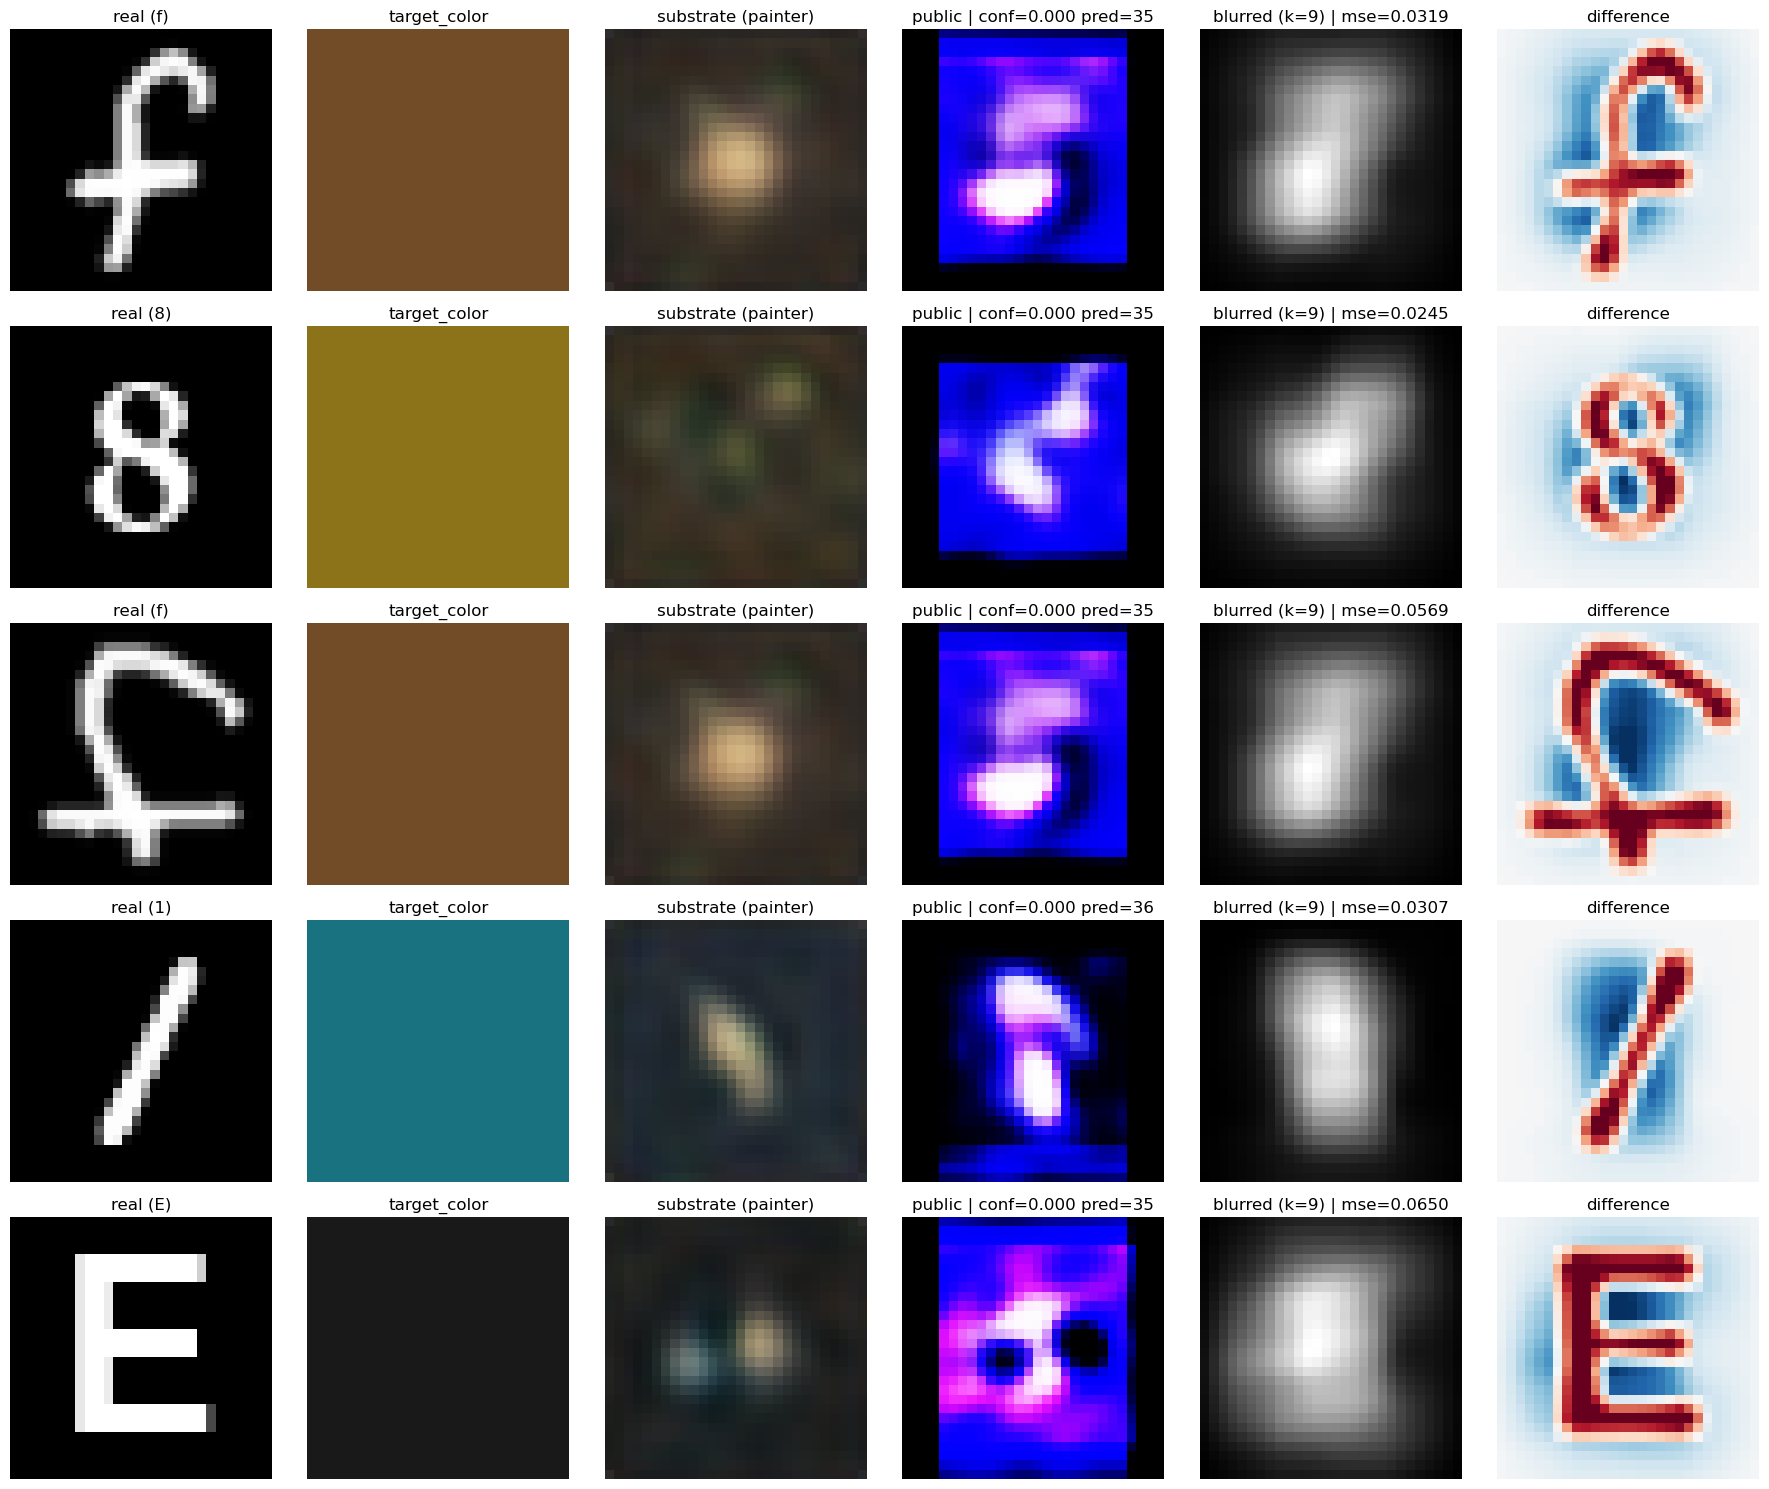

In [39]:
show_full_system(ex_03_06b_model, ex03_06_trainset, n=5)

In [23]:
@torch.no_grad()
def category_breakdown(model, dataset, blur_type, device="cuda", samples_per_class=20):
    model.eval().to(device)
    
    categories = {
        "digits":    [c for c, (kind, _) in enumerate(CLASSES) if kind == "digit"],
        "uppercase": [c for c, (kind, _) in enumerate(CLASSES) if kind == "upper"],
        "lowercase": [c for c, (kind, _) in enumerate(CLASSES) if kind == "lower"],
        "fmnist":    [c for c, (kind, _) in enumerate(CLASSES) if kind == "fmnist"],
        "symbols":   [c for c, (kind, _) in enumerate(CLASSES) if kind == "symbol"],
    }

    class_indices = defaultdict(list)
    for idx in range(len(dataset)):
        _, lbl, _ = dataset[idx]
        class_indices[int(lbl)].append(idx)
        if all(len(class_indices[c]) >= samples_per_class 
               for c in range(NUM_CLASSES) if c in class_indices):
            break

    results = {}
    for cat_name, class_list in categories.items():
        post_losses, baseline_accs = [], []
        for c in class_list:
            if c not in class_indices:
                continue
            for idx in class_indices[c][:samples_per_class]:
                comp, label, target_color = dataset[idx]
                comp         = comp.unsqueeze(0).to(device)
                target_color = target_color.unsqueeze(0).to(device)

                noise  = torch.randn(1, 2, device=device)
                onehot = F.one_hot(torch.tensor([label], device=device),
                                   num_classes=NUM_CLASSES).float()
                public, _ = model(onehot, noise, target_color)

                # --- post loss (generated) ---
                blurred    = blur(public, blur_type, kernel_size=9)
                blurred_1d = blurred.mean(dim=1, keepdim=True)
                real_glyph = comp[:, 3:]
                glyph_mask = (real_glyph > 0.5).float()
                diff_sq    = (blurred_1d - real_glyph) ** 2
                post_loss  = (diff_sq * glyph_mask).sum() / (glyph_mask.sum() + 1e-8)
                post_losses.append(post_loss.item())

                # --- baseline: blur the real glyph and classify ---
                blurred_real    = blur(real_glyph, blur_type, kernel_size=9)
                logits          = ex_03_04a_model(blurred_real)
                pred            = logits.argmax(dim=1).item()
                baseline_accs.append(float(pred == label))

        results[cat_name] = {
            "post_loss":    sum(post_losses) / len(post_losses) if post_losses else float("nan"),
            "baseline_acc": sum(baseline_accs) / len(baseline_accs) if baseline_accs else float("nan"),
        }

    return results

box_results  = category_breakdown(ex_03_06b_model, ex03_06_trainset, "box")
gauss_results = category_breakdown(ex_03_06c_model, ex03_06_trainset, "gauss")

print(f"{'Category':<12} {'Box MSE':>10} {'Gauss MSE':>10} {'Baseline Acc':>13}")
print("-" * 48)
for cat in ["digits", "uppercase", "lowercase", "fmnist", "symbols"]:
    print(f"{cat:<12} {box_results[cat]['post_loss']:>10.4f} "
          f"{gauss_results[cat]['post_loss']:>10.4f} "
          f"{box_results[cat]['baseline_acc']:>13.4f}")

Category        Box MSE  Gauss MSE  Baseline Acc
------------------------------------------------
digits           0.2644     0.2373        0.2900
uppercase        0.2761     0.2306        0.2667
lowercase        0.2633     0.2262        0.2375
fmnist           0.2720     0.2345        0.2600
symbols          0.2723     0.2296        0.2375


In [22]:
# Print as table
print(f"{'Category':<20} {'Box':>8} {'Gaussian':>10}")
print("-" * 40)
for cat in box_results:
    print(f"{cat:<20} {box_results[cat]:>8.4f} {gauss_results[cat]:>10.4f}")

Category                  Box   Gaussian
----------------------------------------
digits                 0.2487     0.2427
uppercase              0.2422     0.2261
lowercase              0.2372     0.2303
fmnist                 0.2363     0.2364
symbols                0.2403     0.2496


In [17]:
len(ex03_06_trainset)

60000